In [1]:
import sys
sys.path.append('../')

In [2]:
import Hamiltonian as ham
import scipy.sparse as sp
import numpy as np
from matplotlib import pyplot as plt
import Evolution as evol
import importlib
from qrisp import QuantumVariable,x
from qrisp.vqe import VQEProblem
from qrisp.vqe.problems.heisenberg import create_heisenberg_init_function
from qrisp.operators import X, Y, Z
import networkx as nx


/home/luca/Documents/QITE-UV/Qite/lib/python3.12/site-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.1 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


In [3]:
def fidelity_pure(psi,phi):
    '''
    input values should be column vectors
    '''
    F=np.abs(psi.conj().T@phi)**2
    return F[0,0]

def variance(psi,H):
    V=np.real((psi.conj().T@H@H@psi)-(psi.conj().T@H@psi)**2)
    return V[0,0]


In [4]:
from qrisp.operators import X, Y, Z
import networkx as nx

def Heisenberg_qr(J, n_qubits):
    H = 0
    for i in range(n_qubits-1):
        H += J*(X(i)*X(i+1) + Y(i)*Y(i+1) + Z(i)*Z(i+1))
    return H

def H_0(J, n_qubits):
    H = 0
    for i in range(0, n_qubits-1, 2):
        H += J*(X(i)*X(i+1) + Y(i)*Y(i+1) + Z(i)*Z(i+1))
    return H

def H_1(J, n_qubits):
    H = 0
    for i in range(1, n_qubits-1, 2):
        H += J*(X(i)*X(i+1) + Y(i)*Y(i+1) + Z(i)*Z(i+1))
    return H


In [5]:
from qrisp.vqe import VQEProblem
from qrisp import QuantumVariable, x
from qrisp.vqe.problems.heisenberg import create_heisenberg_init_function

n_qubits = 8
L = n_qubits
J = 1
H = Heisenberg_qr(J, n_qubits)

print('Computing Eigs')
EH, VH = np.linalg.eigh(H.to_array())
psigs = VH[:, 0:1]
E_gs = EH[0]

def exp_H(qv, t):
    H.trotterization(order=2,method='commuting')(qv, t/10,steps=2)

def ansatz_hva(qv, params):
    H_1(J, n_qubits).trotterization(method='commuting')(qv, t=params[1])
    H_0(J, n_qubits).trotterization(method='commuting')(qv, t=params[0])


def U_10(qv):
    for i in range(qv.size):
        if i % 2 == 0:
            x(qv[i])

G = nx.Graph()
G.add_edges_from([(k, k+1) for k in range(n_qubits-1)])
M = nx.maximal_matching(G)
U_singlet = create_heisenberg_init_function(M)

HVA = VQEProblem(H, ansatz_hva, 2, init_function=U_singlet)
U_HVA = HVA.train_function(QuantumVariable(n_qubits), depth=1, max_iter=100)

def state_prep_hva():
    qv = QuantumVariable(n_qubits)
    U_HVA(qv)
    return qv


# Calculate energy for HVA
def state_prep_hva():
    qv = QuantumVariable(L)
    U_HVA(qv)
    return qv

def state_prep_singlet():
    qv = QuantumVariable(L)
    U_singlet(qv)
    return qv

def state_prep_10():
    qv = QuantumVariable(L)
    U_10(qv)
    return qv


Computing Eigs


In [6]:
# Inspect VQE training and produced circuit
from run_qite import get_statevector
import inspect

print('HVA type:', type(HVA))
candidates = ['opt_result','opt_params','optimal_parameters','result','params','best_params','theta','optimal_theta']
for name in candidates:
    if hasattr(HVA, name):
        print(f'HVA.{name}:', getattr(HVA, name))

print('U_HVA callable:', callable(U_HVA))
try:
    qv = QuantumVariable(n_qubits)
    U_HVA(qv)
    qc = qv.qs.compile()
    print('Compiled HVA circuit ops:', qc.count_ops())
    print('Circuit depth:', qc.depth())
    sv = get_statevector(qc, n_qubits)
    print('HVA fidelity to ground state:', fidelity_pure(psigs, sv.reshape(-1,1)))
except Exception as e:
    print('Error inspecting U_HVA:', e)

# Show some metadata about the returned train function (closure types)
try:
    if hasattr(U_HVA, '__closure__') and U_HVA.__closure__:
        print('U_HVA closure types:', [type(c.cell_contents) for c in U_HVA.__closure__])
    print('U_HVA source available:', hasattr(U_HVA, '__code__'))
except Exception:
    pass


HVA type: <class 'qrisp.algorithms.vqe.vqe_problem.VQEProblem'>
U_HVA callable: True
Compiled HVA circuit ops: {'x': 8, 'h': 46, 'cx': 18, 'cz': 14, 'rz': 21}
Circuit depth: 24
HVA fidelity to ground state: 0.9610943830838994                                
U_HVA closure types: [<class 'int'>, <class 'numpy.ndarray'>, <class 'qrisp.algorithms.vqe.vqe_problem.VQEProblem'>]
U_HVA source available: True


In [7]:
from run_qite import run_QITE

s_values = np.linspace(0.01, 1.5, 20)
steps = 5

In [8]:
results_hva = run_QITE(H, U_HVA, exp_H, s_values, steps,use_statevectors=True)
results_10 = run_QITE(H, U_10, exp_H, s_values, steps,use_statevectors=True)
results_singlet = run_QITE(H, U_singlet, exp_H, s_values, steps,use_statevectors=True)

Simulating 8 qubits.. |                                                 | [  0%]

Step 1/5...                                                                     
Step 2/5...                                                                     
Step 3/5...                                                                     
Step 4/5...                                                                     
Step 5/5...                                                                     
Step 1/5...                                                                     
Step 2/5...                                                                     
Step 3/5...                                                                     
Step 4/5...                                                                     
Step 5/5...                                                                     
Step 1/5...                                                                     
Step 2/5...                                                                     
Step 3/5...                 

In [9]:
fidelities_hva = [fidelity_pure(psigs, results_hva['statevectors'][k].reshape(-1,1)) for k in range(steps+1)]
fidelities_10 = [fidelity_pure(psigs, results_10['statevectors'][k].reshape(-1,1)) for k in range(steps+1)]
fidelities_singlet = [fidelity_pure(psigs, results_singlet['statevectors'][k].reshape(-1,1)) for k in range(steps+1)]

In [10]:
results_10['fidelities'] = fidelities_10
results_hva['fidelities'] = fidelities_hva
results_singlet['fidelities'] = fidelities_singlet

results = {
    'hva': results_hva,
    '1010': results_10,
    'singlet': results_singlet
}

In [12]:
#save
import pickle
with open(f'Heisenberg_N{n_qubits}_J{J}_steps{steps}_DBF_results.pkl', 'wb') as f:
    pickle.dump(results, f)

In [ ]:
#load
import pickle
with open(f'Heisenberg_N{8}_J{0.5}_h{1}_steps{5}_DBF_results.pkl', 'rb') as f:
    results = pickle.load(f)

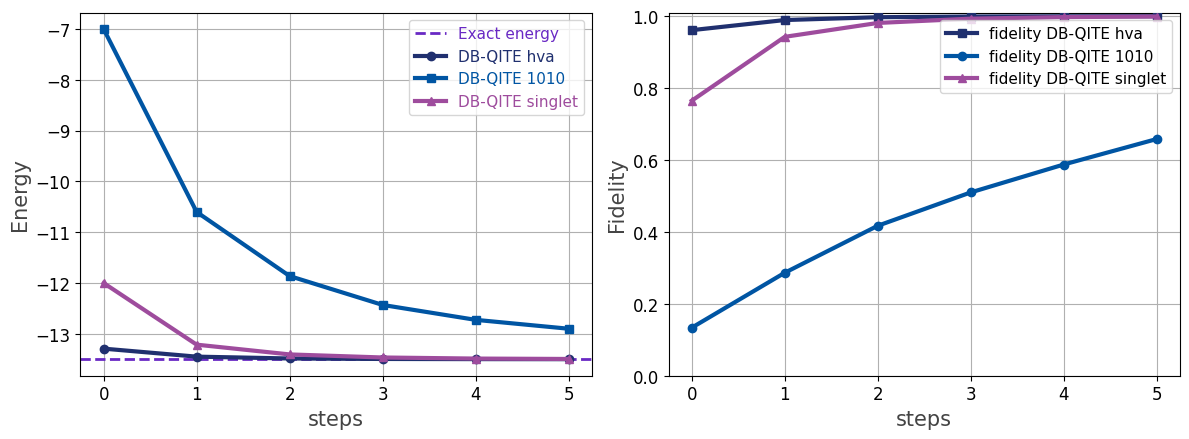

In [11]:
import matplotlib.pyplot as plt
import numpy as np
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Energy plot
ax1.set_xlabel('steps', fontsize=15, color='#444444')
ax1.set_ylabel('Energy', fontsize=15, color='#444444')
ax1.axhline(y=E_gs, color='#6929C4', linestyle='--', linewidth=2, label='Exact energy')
ax1.plot(range(steps+1), results['hva']['optimal_energies'], c='#20306f', marker='o', linestyle='solid', linewidth=3, zorder=3, label='DB-QITE hva')
ax1.plot(range(steps+1), results['1010']['optimal_energies'], c='#0055a3', marker='s', linestyle='solid', linewidth=3, zorder=3, label='DB-QITE 1010')
ax1.plot(range(steps+1), results['singlet']['optimal_energies'], c='#9e4c9d', marker='^', linestyle='solid', linewidth=3, zorder=3, label='DB-QITE singlet')
ax1.legend(fontsize=11, labelcolor='linecolor')
ax1.tick_params(axis='both', labelsize=12)
ax1.grid()

# Fidelity plot
ax2.set_xlabel('steps', fontsize=15, color='#444444')
ax2.set_ylabel('Fidelity', fontsize=15, color='#444444')
ax2.plot(range(steps+1), results['hva']['fidelities'], c='#20306f', marker='s', linestyle='solid', linewidth=3, zorder=3, label='fidelity DB-QITE hva')
ax2.plot(range(steps+1), results['1010']['fidelities'], c='#0055a3', marker='o', linestyle='solid', linewidth=3, zorder=3, label='fidelity DB-QITE 1010')
ax2.plot(range(steps+1), results['singlet']['fidelities'], c='#9e4c9d', marker='^', linestyle='solid', linewidth=3, zorder=3, label='fidelity DB-QITE singlet')
ax2.set_ylim(0.0, 1.01)
ax2.legend(fontsize=11)
ax2.tick_params(axis='both', labelsize=12)
ax2.grid()

plt.savefig(f'Heisenberg_N{n_qubits}_J{J}_steps{steps}_DBF_results.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

In [22]:
import Hamiltonian as ham
import Evolution as evol
from run_qite import get_statevector

T=2
H_acq, H_trot = ham.Heisenberg(J, n_qubits, sparse=True) #T=2

qc_hva = state_prep_hva().qs.compile()
qc_singlet = state_prep_singlet().qs.compile()
qc_10 = state_prep_10().qs.compile()

psi_0_hva = sp.csc_matrix(get_statevector(qc_hva, n_qubits).reshape(-1,1))
psi_0_singlet = sp.csc_matrix(np.real_if_close(get_statevector(qc_singlet, n_qubits).reshape(-1,1)))
psi_0_10 = sp.csc_matrix(np.real_if_close(get_statevector(qc_10, n_qubits).reshape(-1,1)))

D = 4
dt = 0.1
N = 50


Heisenberg model with OBC and Hamiltonian pieces of locality T=2
Succesfull Troterization
The Trotterization consists of 7 terms with the starting qubit of each piece at [0, 1, 2, 3, 4, 5, 6]


In [23]:

print("Computing ACQ")
E_ACQ_hva,psi_ACQ_hva,indx_acq_hva,times_acq_hva,a_acq_hva = evol.ACQ_QC(n_qubits,H_acq,H_trot,D,psi_0_hva,N,dt,methodLS='LU',OBC=True)
E_ACQ_singlet,psi_ACQ_singlet,indx_acq_singlet,times_acq_singlet,a_acq_singlet = evol.ACQ_QC(n_qubits,H_acq,H_trot,D,psi_0_singlet,N,dt,methodLS='LU',OBC=True)
E_ACQ_10,psi_ACQ_10,indx_acq_10,times_acq_10,a_acq_10 = evol.ACQ_QC(n_qubits,H_acq,H_trot,D,psi_0_10,N,dt,methodLS='LU',OBC=True)

Computing ACQ
Computing U at step 0
Computing U at step 1
Computing U at step 2
Computing U at step 3
Computing U at step 4
Energy doubly increased, stopping criteria activated at step 5
Computing U at step 0
Computing U at step 1
Computing U at step 2
Computing U at step 3
Computing U at step 4
Computing U at step 5
Energy doubly increased, stopping criteria activated at step 6
Computing U at step 0
Computing U at step 2
Computing U at step 4
Computing U at step 6
Computing U at step 8
Computing U at step 9
Computing U at step 11
Computing U at step 13
Computing U at step 14
Computing U at step 15
Energy doubly increased, stopping criteria activated at step 16


In [31]:
a_acq_hva

[array([[ 3.92947972e-09+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
         ...,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
         -2.81015154e-15+0.j],
        [-1.07269174e-06+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
         ...,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          8.72306364e-07+0.j],
        [-5.52834447e-16+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
         ...,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
          2.06220335e-15+0.j],
        ...,
        [ 9.86380417e-15+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
         ...,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
         -4.70032358e-15+0.j],
        [ 9.98539031e-07+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
         ...,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
         -1.74559565e-06+0.j],
        [-1.08165962e-16+0.j, -1.08165962e-16+0.j, -1.08165962e-16+0.j,
         ..., -2.03992961e-14+0.j, -5.28606345e-15+0.j,
          2.42889448e-14+0.j]], shape=(7, 256)),
 array([[-1.243

In [24]:
import PauliStrings as ps
import run_qite
importlib.reload(run_qite)
from run_qite import build_acq_circuit_qrisp

num_paulis_real,PD_real,fail_real = ps.real_OBC(H_trot,D,n_qubits,PDstr=True)
num_paulis_gen,PD_gen,fail_gen = ps.general_OBC(H_trot,D,n_qubits,PDstr=True)

steps_acq_singlet = len(a_acq_singlet)
steps_acq_hva = len(a_acq_hva)
steps_acq_10 = len(a_acq_10)

In [37]:
importlib.reload(run_qite)
from run_qite import build_acq_circuit_qrisp

circuit_ops_10 = {}
circuits_10 = {}

for step_acq in range(steps_acq_10+1): 
    qc = build_acq_circuit_qrisp(n_qubits,D,T,PD_real,a_acq_10,times_acq_10,step_acq,U_10,debug=False)
    tqc = qc.transpile(basis_gates=['cz','u'])

    circuits_10[step_acq] = qc
    circuit_ops_10[step_acq] = tqc.count_ops()
    print(f"Step {step_acq}: {tqc.count_ops()}")


circuit_ops_hva = {}
circuits_hva = {}

for step_acq in range(steps_acq_hva+1):
    qc = build_acq_circuit_qrisp(n_qubits,D,T,PD_gen,a_acq_hva,times_acq_hva,step_acq,U_HVA,debug=False)
    tqc = qc.transpile(basis_gates=['cz','u'])

    circuits_hva[step_acq] = qc
    circuit_ops_hva[step_acq] = tqc.count_ops()
    print(f"Step {step_acq}: {tqc.count_ops()}")

circuit_ops_singlet = {}
circuits_singlet = {}

for step_acq in range(steps_acq_singlet+1):
    qc = build_acq_circuit_qrisp(n_qubits,D,T,PD_real,a_acq_singlet,times_acq_singlet,step_acq,U_singlet,debug=False)
    tqc = qc.transpile(basis_gates=['cz','u'])

    circuits_singlet[step_acq] = qc
    circuit_ops_singlet[step_acq] = tqc.count_ops()
    print(f"Step {step_acq}: {tqc.count_ops()}")



Step 0: {'u3': 4}
Step 1: {'u3': 114, 'cz': 109}
Step 2: {'u3': 681, 'cz': 778}
Step 3: {'u3': 1274, 'cz': 1483}
Step 4: {'u3': 1866, 'cz': 2188}
Step 5: {'u3': 2458, 'cz': 2893}
Step 6: {'u3': 3051, 'cz': 3598}
Step 7: {'u3': 3640, 'cz': 4303}
Step 8: {'u3': 4232, 'cz': 5008}
Step 9: {'u3': 4823, 'cz': 5713}
Step 0: {'u3': 58, 'cz': 25}
Step 1: {'u3': 723, 'cz': 775}
Step 2: {'u3': 1363, 'cz': 1492}
Step 3: {'u3': 2051, 'cz': 2250}
Step 4: {'u3': 2713, 'cz': 2981}
Step 0: {'u3': 12, 'cz': 4}
Step 1: {'u3': 171, 'cz': 178}
Step 2: {'u3': 503, 'cz': 551}
Step 3: {'u3': 828, 'cz': 930}
Step 4: {'u3': 1144, 'cz': 1301}
Step 5: {'u3': 1477, 'cz': 1670}


In [38]:
from run_qite import get_statevector,compute_moments

energies_acq_10 = [compute_moments(get_statevector(circuits_10[step],n_qubits),H_acq)[0] for step in range(steps_acq_10+1)]
fidelities_acq_10 = [fidelity_pure(psigs, get_statevector(circuits_10[step],n_qubits).reshape(-1,1)) for step in range(steps_acq_10+1)]

energies_acq_hva = [compute_moments(get_statevector(circuits_hva[step],n_qubits),H_acq)[0] for step in range(steps_acq_hva+1)]
fidelities_acq_hva = [fidelity_pure(psigs, get_statevector(circuits_hva[step],n_qubits).reshape(-1,1)) for step in range(steps_acq_hva+1)]

energies_acq_singlet = [compute_moments(get_statevector(circuits_singlet[step],n_qubits),H_acq)[0] for step in range(steps_acq_singlet+1)]
fidelities_acq_singlet = [fidelity_pure(psigs, get_statevector(circuits_singlet[step],n_qubits).reshape(-1,1)) for step in range(steps_acq_singlet+1)]

In [39]:
circuit_data_hva = {
    'circuits': circuits_hva,
    'circuit_ops': circuit_ops_hva,
    'energies': energies_acq_hva,
    'fidelities': fidelities_acq_hva
}

circuit_data_10 = {
    'circuits': circuits_10,
    'circuit_ops': circuit_ops_10,
    'energies': energies_acq_10,
    'fidelities': fidelities_acq_10
}

circuit_data_singlet = {
    'circuits': circuits_singlet,
    'circuit_ops': circuit_ops_singlet,
    'energies': energies_acq_singlet,
    'fidelities': fidelities_acq_singlet
}

circuit_data_acq = {
    '1010': circuit_data_10,
    'hva': circuit_data_hva,
    'singlet': circuit_data_singlet
}

In [42]:
#save
import pickle
with open(f'Heisenberg_N{n_qubits}_J{J}_ACQ_D{D}_results.pkl', 'wb') as f:
    pickle.dump(circuit_data_acq, f)

In [ ]:
#load
import pickle
with open(f'Heisenberg_N{n_qubits}_J{J}_ACQ_D{D}_results.pkl', 'rb') as f:
    circuit_data_acq = pickle.load(f)

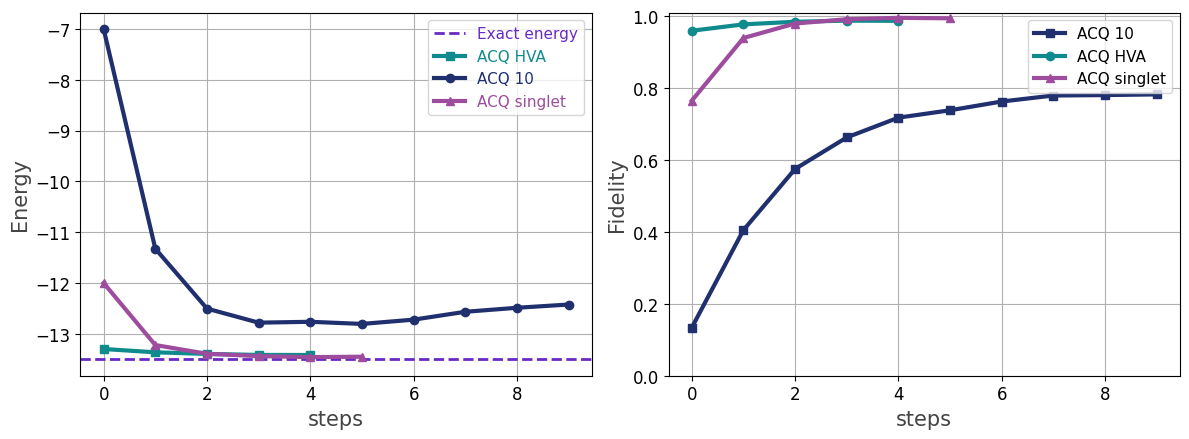

In [40]:
from run_qite import get_statevector,compute_moments

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
# Energy plot
ax1.set_xlabel('steps', fontsize=15, color='#444444')
ax1.set_ylabel('Energy', fontsize=15, color='#444444')
ax1.axhline(y=E_gs, color='#6929C4', linestyle='--', linewidth=2, label='Exact energy')
ax1.plot(range(steps_acq_hva+1), energies_acq_hva, c='#0f8b8d', marker='s', linestyle='solid', linewidth=3, zorder=3, label='ACQ HVA')
ax1.plot(range(steps_acq_10+1), energies_acq_10, c='#20306f', marker='o', linestyle='solid', linewidth=3, zorder=3, label='ACQ 10')
ax1.plot(range(steps_acq_singlet+1), energies_acq_singlet, c='#9e4c9d', marker='^', linestyle='solid', linewidth=3, zorder=3, label='ACQ singlet')
ax1.legend(fontsize=11, labelcolor='linecolor')
ax1.tick_params(axis='both', labelsize=12)
ax1.grid()

# Fidelity plot
ax2.set_xlabel('steps', fontsize=15, color='#444444')
ax2.set_ylabel('Fidelity', fontsize=15, color='#444444')
ax2.plot(range(steps_acq_10+1), fidelities_acq_10, c='#20306f', marker='s', linestyle='solid', linewidth=3, zorder=3, label='ACQ 10')
ax2.plot(range(steps_acq_hva+1), fidelities_acq_hva, c='#0f8b8d', marker='o', linestyle='solid', linewidth=3, zorder=3, label='ACQ HVA')
ax2.plot(range(steps_acq_singlet+1), fidelities_acq_singlet, c='#9e4c9d', marker='^', linestyle='solid', linewidth=3, zorder=3, label='ACQ singlet')
ax2.set_ylim(0.0, 1.01)
ax2.legend(fontsize=11, loc='upper right')
ax2.set_ylim(0.0, 1.01)
ax2.legend(fontsize=11)
ax2.tick_params(axis='both', labelsize=12)
ax2.grid()

plt.savefig(f'Heisenberg_N{n_qubits}_J{J}_ACQ_D{D}_results.png', dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()


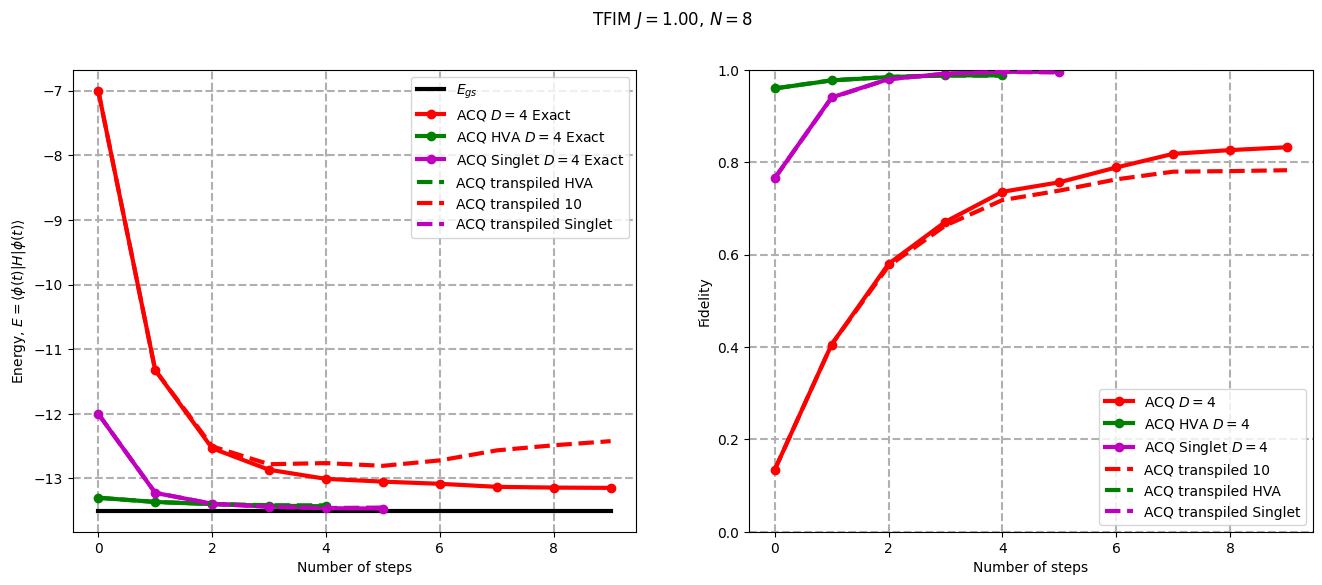

In [47]:
F_ACQ_10=np.zeros(N+1)
for i in range(N+1):
    F_ACQ_10[i]=fidelity_pure(psigs,psi_ACQ_10[:,i].todense())

F_ACQ_hva=np.zeros(N+1)
for i in range(N+1):
    F_ACQ_hva[i]=fidelity_pure(psigs,psi_ACQ_hva[:,i].todense())

F_ACQ_singlet=np.zeros(N+1)
for i in range(N+1):
    F_ACQ_singlet[i]=fidelity_pure(psigs,psi_ACQ_singlet[:,i].todense())

plt.figure(figsize=(16, 6))

plt.suptitle("TFIM $J=%.2f$, $N=%d$"%(J,n_qubits))
plt.subplot(1,2,1)
plt.plot(range(len(indx_acq_10)),[E_gs]*len(indx_acq_10),'-k',linewidth=3,label='$E_{gs}$')
plt.plot(range(len(indx_acq_10)),E_ACQ_10[indx_acq_10],'-ro',linewidth=3,label='ACQ $D=%d$ Exact'%D)
plt.plot(range(len(indx_acq_hva)),E_ACQ_hva[indx_acq_hva],'-go',linewidth=3,label='ACQ HVA $D=%d$ Exact'%D)
plt.plot(range(len(indx_acq_singlet)),E_ACQ_singlet[indx_acq_singlet],'-mo',linewidth=3,label='ACQ Singlet $D=%d$ Exact'%D)
plt.plot(range(steps_acq_hva+1), energies_acq_hva, c='g', marker='', linestyle='dashed', linewidth=3, zorder=3, label='ACQ transpiled HVA')
plt.plot(range(steps_acq_10+1), energies_acq_10, c='r', marker='', linestyle='dashed', linewidth=3, zorder=3, label='ACQ transpiled 10')
plt.plot(range(steps_acq_singlet+1), energies_acq_singlet, c='m', marker='', linestyle='dashed', linewidth=3, zorder=3, label='ACQ transpiled Singlet')

plt.xlabel("Number of steps")
plt.ylabel("Energy, $E=\\langle \\phi(t)|H|\\phi(t)\\rangle$")
#plt.yticks(np.arange(-12, 10, step=4))
plt.legend()
plt.grid(linestyle = '--', linewidth = 1.5)


plt.subplot(1,2,2)
plt.plot(range(len(indx_acq_10)),F_ACQ_10[indx_acq_10],'-ro',linewidth=3,label='ACQ $D=%d$'%D)
plt.plot(range(len(indx_acq_hva)),F_ACQ_hva[indx_acq_hva],'-go',linewidth=3,label='ACQ HVA $D=%d$'%D)
plt.plot(range(len(indx_acq_singlet)),F_ACQ_singlet[indx_acq_singlet],'-mo',linewidth=3,label='ACQ Singlet $D=%d$'%D)
plt.plot(range(steps_acq_10+1), fidelities_acq_10, c='r', marker='', linestyle='dashed', linewidth=3, zorder=3, label='ACQ transpiled 10')
plt.plot(range(steps_acq_hva+1), fidelities_acq_hva, c='g', marker='', linestyle='dashed', linewidth=3, zorder=3, label='ACQ transpiled HVA')
plt.plot(range(steps_acq_singlet+1), fidelities_acq_singlet, c='m', marker='', linestyle='dashed', linewidth=3, zorder=3, label='ACQ transpiled Singlet')
plt.xlabel("Number of steps")
plt.ylabel("Fidelity")
plt.ylim(0,1)
plt.legend()
plt.grid(linestyle = '--', linewidth = 1.5)

plt.savefig(f'EXACT_VS_TRANSPILED_HEISENBERG_N{n_qubits}_J{J}_ACQ_D{D}_results.png', dpi=300, bbox_inches='tight')


In [32]:
# Diagnostics: locate empty ACQ coefficient blocks (singlet)
for step in range(len(a_acq_singlet)):
    for k in range(a_acq_singlet[step].shape[0]):
        if np.all(np.abs(a_acq_singlet[step][k, :]) <= 1e-10):
            print("all-zero a for singlet:", step, k)

all-zero a for singlet: 0 0
all-zero a for singlet: 0 2
all-zero a for singlet: 0 4
all-zero a for singlet: 0 6
